# Trabalho 2
### Classificação - k-Nearest Neighbour (kNN)

- João Henrique Galleazzi
- Maria Júlia Testoni
- Micael Conti



===== RESULTADOS PARA k = 1 =====
Número de acertos: 48
Total de amostras: 50
Acurácia: 0.96


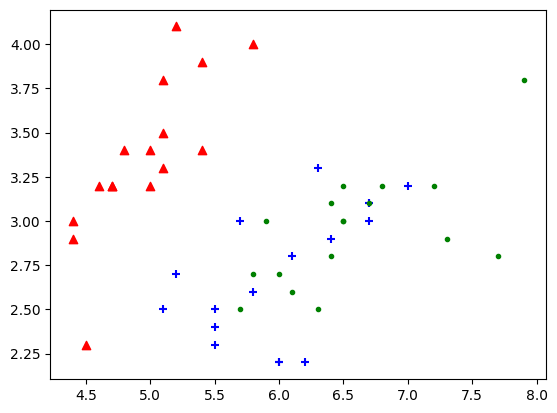


===== RESULTADOS PARA k = 10 =====
Número de acertos: 47
Total de amostras: 50
Acurácia: 0.94


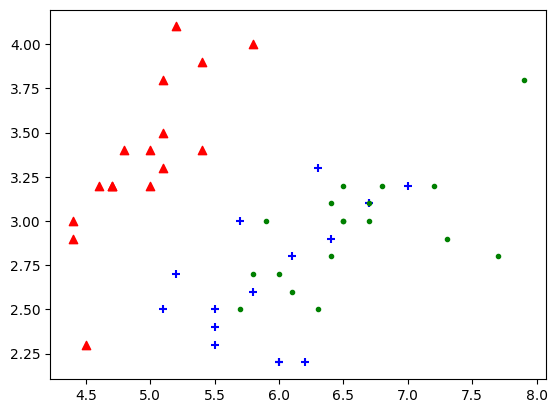

In [ ]:
import scipy.io as scipy
import numpy
import matplotlib.pyplot as plt

# Funções passadas pela professora
def visualizaPontos(dados, rotulos, d1, d2):
    fig, ax = plt.subplots()
    ax.scatter(getDadosRotulo(dados, rotulos, 1, d1), getDadosRotulo(dados, rotulos, 1, d2), c='red' , marker='^')
    ax.scatter(getDadosRotulo(dados, rotulos, 2, d1), getDadosRotulo(dados, rotulos, 2, d2), c='blue' , marker='+')
    ax.scatter(getDadosRotulo(dados, rotulos, 3, d1), getDadosRotulo(dados, rotulos, 3, d2), c='green', marker='.')
    plt.show()

def getDadosRotulo(dados, rotulos, rotulo, indice):
  ret = []
  for idx in range(0, len(dados)):
      if(rotulos[idx] == rotulo):
          ret.append(dados[idx][indice])
  return ret


# ====================
# Funções customizadas
# ====================
def meuKnn(dadosTrain, rotuloTrain, dadosTeste, k):
    resultados = []

    for dadoTeste in dadosTeste:
        vetorOrdenador = []

        # Calcula a distância do dado de teste para cada dado de treino
        for i in range(len(dadosTrain)):
            dadoTrain = dadosTrain[i]
            # Distância Euclidiana
            soma = 0
            for j in range(len(dadoTeste)):
                soma += (dadoTeste[j] - dadoTrain[j]) ** 2
            distancia = soma ** 0.5

            # garante que o rótulo não seja numpy.ndarray
            rotulo = rotuloTrain[i]
            if isinstance(rotulo, numpy.ndarray):
                rotulo = rotulo.item()

            vetorOrdenador.append((distancia, rotulo))

        # Ordena pelas distâncias (menor primeiro)
        vetorOrdenador.sort(key=lambda x: x[0])

        # Pega os k vizinhos mais próximos
        k_vizinhos = vetorOrdenador[:k]

        # Faz votação majoritária
        contagem = {}
        for _, rotulo in k_vizinhos:
            if rotulo in contagem:
                contagem[rotulo] += 1
            else:
                contagem[rotulo] = 1

        # Escolhe o rótulo mais frequente
        rotuloPrevisto = max(contagem, key=contagem.get)
        resultados.append(rotuloPrevisto)

    return resultados


# dados
mat = scipy.loadmat('grupoDados1.mat')
grupoTest = mat['grupoTest']
grupoTrain =  mat['grupoTrain']
testRots =  mat['testRots']
trainRots =  mat['trainRots']

# ajuste feito uma única vez
testRots = testRots.flatten()

# k = 1 e acuracia = 96%
rotuloPrevisto = meuKnn(grupoTrain, trainRots, grupoTest, 1)
rotuloPrevisto = numpy.array(rotuloPrevisto)

estaCorreto = rotuloPrevisto == testRots
numCorreto = numpy.sum(estaCorreto)
totalNum = len(testRots)
acurácia = numCorreto / totalNum

print("\n===== RESULTADOS PARA k = 1 =====")
print("Acurácia:", acurácia)

rotuloPrevisto = rotuloPrevisto.astype(int)
visualizaPontos(grupoTest, rotuloPrevisto, 0, 1)


# k = 10 e acuracia = 94%
rotuloPrevisto = meuKnn(grupoTrain, trainRots, grupoTest, 10)
rotuloPrevisto = numpy.array(rotuloPrevisto)

estaCorreto = rotuloPrevisto == testRots
numCorreto = numpy.sum(estaCorreto)
totalNum = len(testRots)
acurácia = numCorreto / totalNum

print("\n===== RESULTADOS PARA k = 10 =====")
print("Acurácia:", acurácia)

rotuloPrevisto = rotuloPrevisto.astype(int)
visualizaPontos(grupoTest, rotuloPrevisto, 0, 1)

Grupo de Dados 1:
- Q1.1. Qual é a acurácia máxima que você consegue da classificação?

- Q1.2. É necessário ter todas as características (atributos) para obter a acurácia máxima para esta classificação?


===== RESULTADOS PARA k = 3 =====
Número de acertos: 49
Total de amostras: 50
Acurácia: 0.98


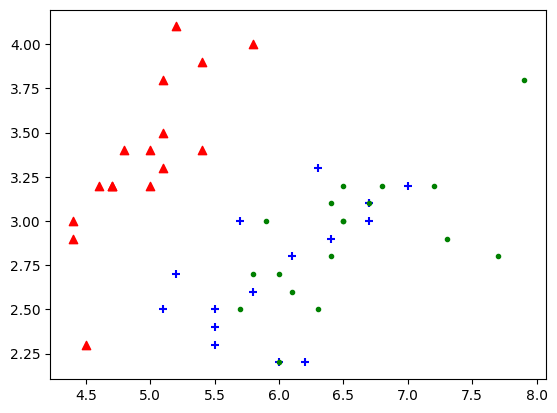

Não é necessário ter todos os atributos para a acurácia máxima, somente caracteristicas relevantes


In [ ]:
# Grupo de dados 1

# Q1.1
# k = 3 e acuracia = 98%
rotuloPrevisto = meuKnn(grupoTrain, trainRots, grupoTest, 3)
rotuloPrevisto = numpy.array(rotuloPrevisto)

estaCorreto = rotuloPrevisto == testRots
numCorreto = numpy.sum(estaCorreto)
totalNum = len(testRots)
acurácia = numCorreto / totalNum

print("\n===== RESULTADOS PARA k = 3 =====")
print("Acurácia máxima:", acurácia)

rotuloPrevisto = rotuloPrevisto.astype(int)
visualizaPontos(grupoTest, rotuloPrevisto, 0, 1)
# Q1.2. É necessário ter todas as características (atributos) para obter a acurácia máxima para esta classificação?
print("Não é necessário ter todos os atributos para a acurácia máxima, somente caracteristicas relevantes")

Grupo de Dados 2:
- Q2.1: Aplique seu kNN a este problema. Qual é a sua acurácia de classificação?

- Q2.2: A acurácia pode ser igual a 98% com o kNN. Descubra por que o resultado atual é muito menor. Ajuste o conjunto de dados ou k de tal forma que a acurácia se torne 98% e explique o que você fez e por quê.


===== RESULTADOS PARA k = 17 =====
Número de acertos: 45
Total de amostras: 60
Acurácia: 0.75


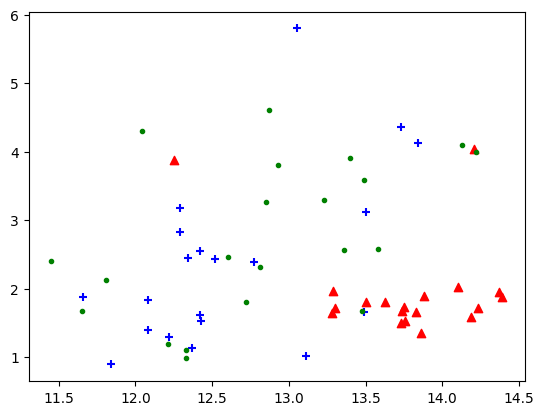


===== RESULTADOS PARA k = 3 =====
Número de acertos: 59
Total de amostras: 60
Acurácia: 0.9833333333333333
Foi necessário normalizar os dados


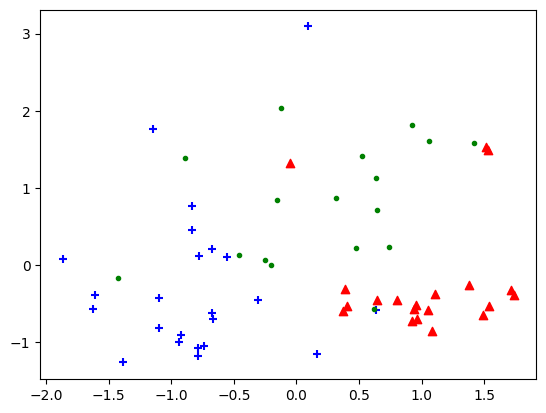

In [ ]:
def normalizar(dadosTrain, dadosTest):
    media = numpy.mean(dadosTrain, axis=0)
    desvio = numpy.std(dadosTrain, axis=0)

    desvio[desvio == 0] = 1

    dadosTrain_norm = (dadosTrain - media) / desvio
    dadosTest_norm = (dadosTest - media) / desvio

    return dadosTrain_norm, dadosTest_norm

# dados
mat = scipy.loadmat('grupoDados2.mat')
grupoTest = mat['grupoTest']
grupoTrain =  mat['grupoTrain']
testRots =  mat['testRots']
trainRots =  mat['trainRots']

testRots = testRots.flatten()

# Q2.1: Aplique seu kNN a este problema. Qual é a sua acurácia de classificação?
rotuloPrevisto = meuKnn(grupoTrain, trainRots, grupoTest, 17)
rotuloPrevisto = numpy.array(rotuloPrevisto)

estaCorreto = rotuloPrevisto == testRots
numCorreto = numpy.sum(estaCorreto)
totalNum = len(testRots)
acurácia = numCorreto / totalNum

print("\n===== RESULTADOS PARA k = 17 =====")
print("Número de acertos:", numCorreto)
print("Total de amostras:", totalNum)
print("Acurácia:", acurácia)

rotuloPrevisto = rotuloPrevisto.astype(int)
visualizaPontos(grupoTest, rotuloPrevisto, 0, 1)

#  Q2.2: A acurácia pode ser igual a 98% com o kNN. Descubra por que o resultado atual é muito menor. Ajuste o conjunto de dados ou k de
# tal forma que a acurácia se torne 98% e explique o que você fez e por quê.
grupoTrain, grupoTest = normalizar(grupoTrain, grupoTest)

rotuloPrevisto = meuKnn(grupoTrain, trainRots, grupoTest, 3)
rotuloPrevisto = numpy.array(rotuloPrevisto)

estaCorreto = rotuloPrevisto == testRots
numCorreto = numpy.sum(estaCorreto)
totalNum = len(testRots)
acurácia = numCorreto / totalNum

print("\n===== RESULTADOS PARA k = 3 =====")
print("Número de acertos:", numCorreto)
print("Total de amostras:", totalNum)
print("Acurácia:", acurácia)
print("Foi necessário normalizar os dados")

rotuloPrevisto = rotuloPrevisto.astype(int)
visualizaPontos(grupoTest, rotuloPrevisto, 0, 1)


Grupo de Dados 3:
- Q3.1: Aplique o kNN ao problema usando k = 1. Qual é a acurácia na classificação?

- Q3.2: A acurácia pode ser igual a 92% com o kNN. Descubra por que o resultado atual é muito menor. Ajuste o conjunto de dados ou k de tal forma que a acurácia se torne 92% e explique o que você fez e por quê.


===== RESULTADOS PARA k = 1 =====
Acurácia: 0.7


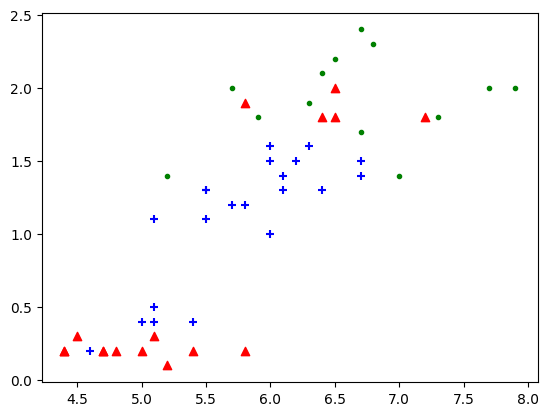


===== RESULTADOS PARA k = 10 =====
Acurácia: 0.92
Testei qual era o melhor valor para k (fazendo um for mesmo)


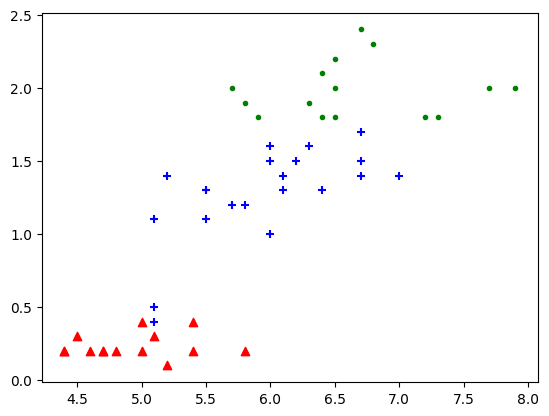

In [ ]:
# dados
mat = scipy.loadmat('grupoDados3.mat')
grupoTest = mat['grupoTest']
grupoTrain =  mat['grupoTrain']
testRots =  mat['testRots']
trainRots =  mat['trainRots']

testRots = testRots.flatten()

# Q3.1
rotuloPrevisto = meuKnn(grupoTrain, trainRots, grupoTest, 1)
rotuloPrevisto = numpy.array(rotuloPrevisto)

estaCorreto = rotuloPrevisto == testRots
numCorreto = numpy.sum(estaCorreto)
totalNum = len(testRots)
acurácia = numCorreto / totalNum

print("\n===== RESULTADOS PARA k = 1 =====")
print("Acurácia:", acurácia)

rotuloPrevisto = rotuloPrevisto.astype(int)
visualizaPontos(grupoTest, rotuloPrevisto, 0, 1)

# Q3.2
rotuloPrevisto = meuKnn(grupoTrain, trainRots, grupoTest, 10)
rotuloPrevisto = numpy.array(rotuloPrevisto)

estaCorreto = rotuloPrevisto == testRots
numCorreto = numpy.sum(estaCorreto)
totalNum = len(testRots)
acurácia = numCorreto / totalNum

print("\n===== RESULTADOS PARA k = 10 =====")
print("Acurácia:", acurácia)
print("Testei qual era o melhor valor para k (fazendo um for mesmo)")

rotuloPrevisto = rotuloPrevisto.astype(int)
visualizaPontos(grupoTest, rotuloPrevisto, 0, 1)

Grupo de Dados 4:
- Q4.1: Aplique seu algoritmo K-NN ao problema. Qual é a sua acurácia de classificação?

- Q4.2: A acurácia pode chegar a 92% com o K-NN. Descubra por que o resultado atual é muito menor. Ajuste o conjunto de dados ou o valor de k de forma que a acurácia atinja 92% e explique o que você fez e por quê. Observe que, desta vez, há mais de um problema...


===== RESULTADOS PARA k = 1 =====
Acurácia: 0.7166666666666667


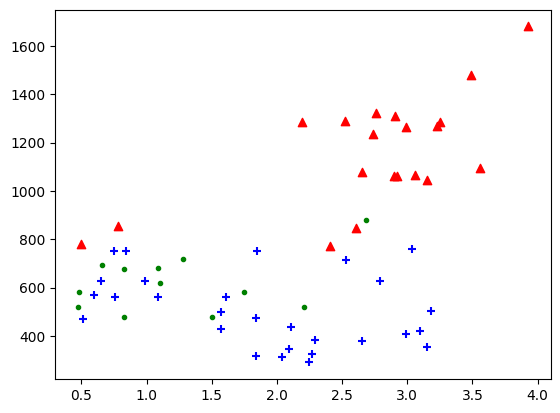


===== RESULTADOS PARA k = 17 =====
Acurácia: 0.9333333333333333
Além de normalizar foi necessário remover uma coluna


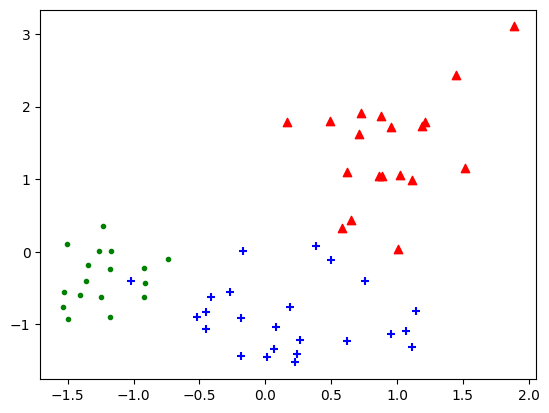

In [ ]:
# dados
mat = scipy.loadmat('grupoDados4.mat')
grupoTest = mat['testSet']
grupoTrain =  mat['trainSet']
testRots =  mat['testLabs']
trainRots =  mat['trainLabs']

testRots = testRots.flatten()

# Q4.1
rotuloPrevisto = meuKnn(grupoTrain, trainRots, grupoTest, 1)
rotuloPrevisto = numpy.array(rotuloPrevisto)

estaCorreto = rotuloPrevisto == testRots
numCorreto = numpy.sum(estaCorreto)
totalNum = len(testRots)
acurácia = numCorreto / totalNum

print("\n===== RESULTADOS PARA k = 1 =====")
print("Acurácia:", acurácia)

rotuloPrevisto = rotuloPrevisto.astype(int)
visualizaPontos(grupoTest, rotuloPrevisto, 0, 1)

# Q4.2
grupoTrain = numpy.delete(grupoTrain, 2, axis=1)
grupoTest = numpy.delete(grupoTest, 2, axis=1)
grupoTrain, grupoTest = normalizar(grupoTrain, grupoTest)

rotuloPrevisto = meuKnn(grupoTrain, trainRots, grupoTest, 17)
rotuloPrevisto = numpy.array(rotuloPrevisto)

estaCorreto = rotuloPrevisto == testRots
numCorreto = numpy.sum(estaCorreto)
totalNum = len(testRots)
acurácia = numCorreto / totalNum

print("\n===== RESULTADOS PARA k = 17 =====")
print("Acurácia:", acurácia)
print("Além de normalizar foi necessário remover uma coluna")

rotuloPrevisto = rotuloPrevisto.astype(int)
visualizaPontos(grupoTest, rotuloPrevisto, 0, 1)